## Задание 1

Скачайте материалы к занятию.
Проанализируйте 6 временных рядов из папки Series и сделайте их стационарными:
- monthly-sales-of-company-x-jan-6.csv
- monthly-boston-armed-robberies-j.csv
- international-airline-passengers.csv
- mean-monthly-air-temperature-deg.csv
- weekly-closings-of-the-dowjones-.csv
- daily-total-female-births-in-cal.csv

#### Подготовка данных и функций

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox

In [3]:
sales_of_company_x = pd.read_csv("Series/monthly-sales-of-company-x-jan-6.csv")
robberies_in_boston = pd.read_csv("Series/monthly-boston-armed-robberies-j.csv")
airlines_passengers = pd.read_csv("Series/international-airline-passengers.csv")
mean_monthly_temp = pd.read_csv("Series/mean-monthly-air-temperature-deg.csv")
dowjones_closing = pd.read_csv("Series/weekly-closings-of-the-dowjones-.csv")
female_births = pd.read_csv("Series/daily-total-female-births-in-cal.csv")

In [19]:
robberies_in_boston['Count'][14]

63

In [4]:
all_series = {
    "Monthly sales of company X": sales_of_company_x["Count"],
    "Monthly Boston armed robberies": robberies_in_boston["Count"],
    "International airline passengers: monthly totals in thousands": airlines_passengers["Count"],
    "Mean monthly air temperature (Deg. F) Nottingham Castle": mean_monthly_temp["Deg"],
    "Weekly closings of the Dow-Jones industrial average": dowjones_closing["Close"],
    "Daily total female births in California": female_births["Count"]
}

In [118]:
def print_graph (data):
    with plt.style.context('bmh'):
        plt.figure(figsize=(16, 8))
        plt.plot(data, color='blue')

In [127]:
## отрисовка точек для определение сезонности (периода ряда)
def plot_ts_and_points(ts, start_point, step):
    new_series = [None for i in range(len(ts))] # [None,None,None....]
    for i in range(len(ts)): ##[0,1,2,3...]
        pos = start_point + step * i #[2,6,14...]
        if pos >= len(ts):
            break
        new_series[pos] = ts[pos] #[50,60,63] - записываем в словарь значения цены в столбце дата-фрейма под новыми позициями 
    new_series = pd.Series(new_series)
    with plt.style.context('bmh'):
        plt.figure(figsize=(16, 8))
        ts_ax = plt.axes()
        ts.plot(ax=ts_ax, color='blue')
        new_series.plot(ax=ts_ax, style='ro') ## отрисовываем точки, которая отображает значение цены через каждые step единиц

In [128]:
## проверка гипотезы стационарности через тест Дики-Фулера
def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC') ## количество лагов выбирается таким образом, чтобы минимизировать соответствующий информационный критерий.
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [6]:
for i, key in enumerate(all_series.keys()):
    x = i % 2
    y = int((i - x) / 2)
    print(x,y)

0 0
1 0
0 1
1 1
0 2
1 2


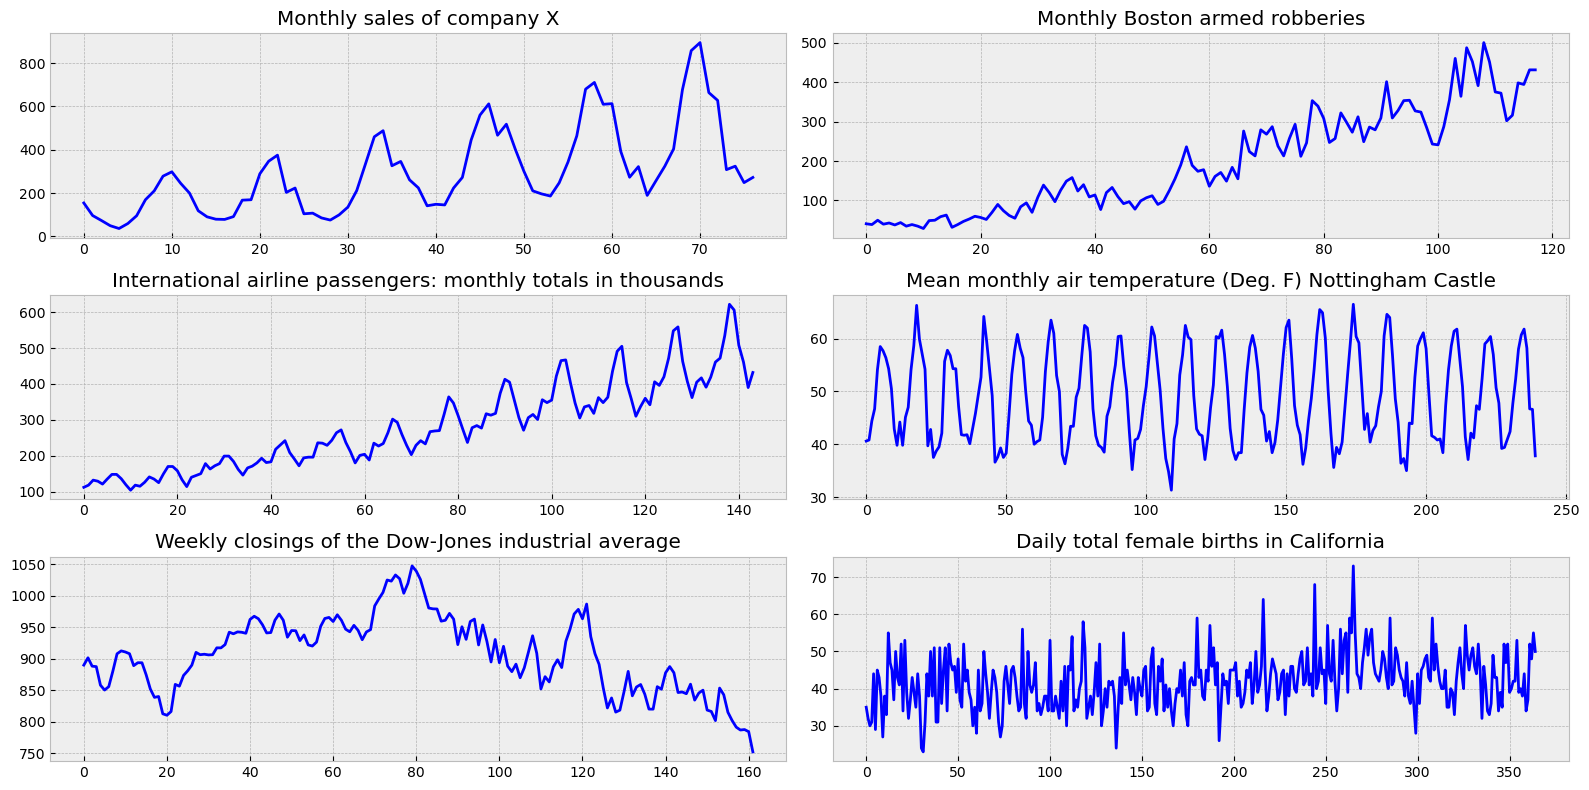

In [8]:
with plt.style.context('bmh'):
    plt.figure(figsize=(16, 8))
    layout = (3, 2)
    for i, key in enumerate(all_series.keys()):
        x = i % 2
        y = int((i - x) / 2) ## задаем координаты области, в которой будет находиться подграфик 
        
        ts_ax = plt.subplot2grid(layout, (y, x)) ## создаем область для подграфика 
        all_series[key].plot(ax=ts_ax, color='blue')
        ts_ax.set_title(key)
        
    plt.tight_layout() ## подгоняет графики, чтобы они не налезали друг на друга

#### Анализ ряда "Monthly sales of company X" и приведение его к стационарному виду

График имеет четко выраженный тренд и сезонность, соответственно, можно продифференцировать график по сезонности. 

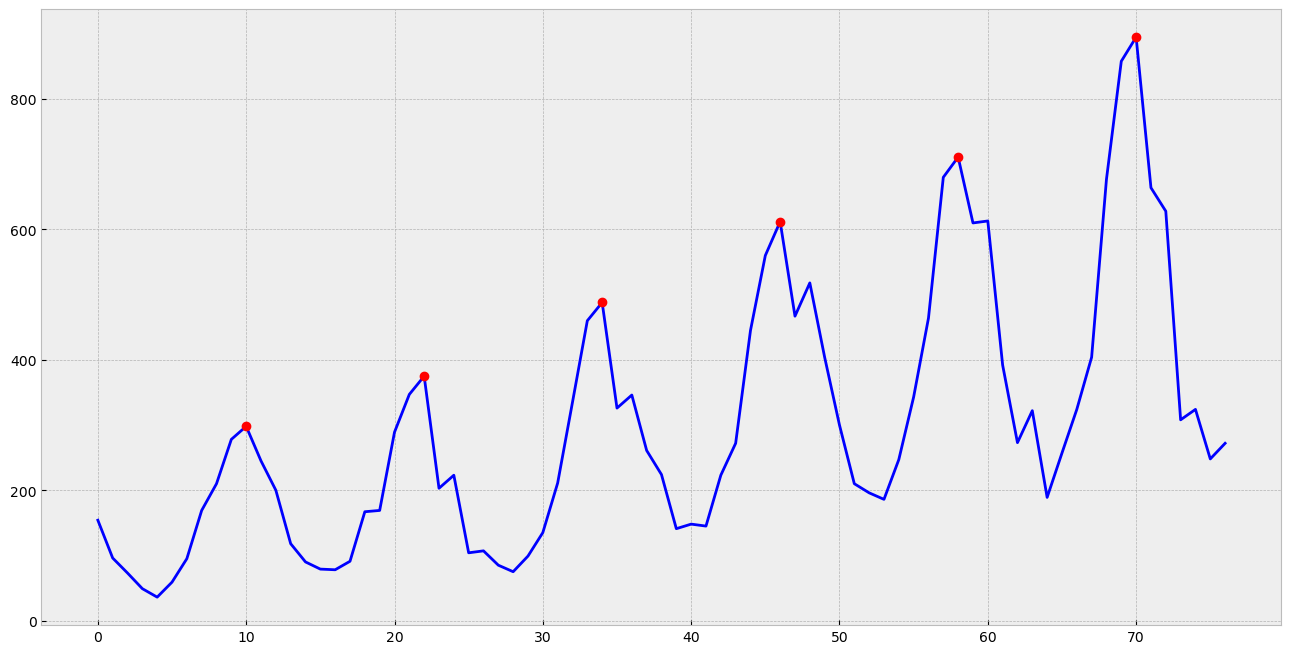

In [61]:
plot_ts_and_points(all_series["Monthly sales of company X"], 10, 12)

Расстояние между двумя одинаковыми точками (период) = 12. Следовательно, будем дифференцировать ряд по числу 12

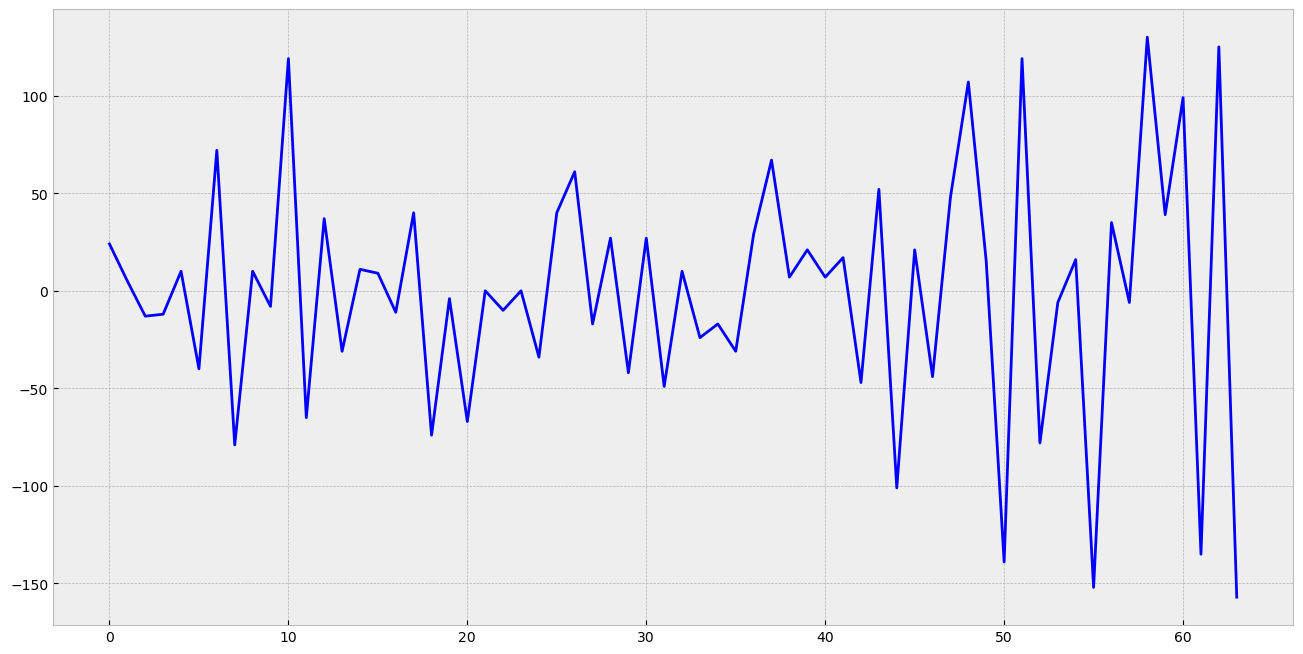

In [119]:
series = np.diff(all_series['Monthly sales of company X'], 1)
series = series[:-12] - series[12:] ## будем из каждого элемента вычитать элемент, стоящий через 12 единиц от этого - это дифференцирование с лагом 12
## при дифференцировании первого порядка из каждого элемента вычитается следуюший
print_graph(series)


Ряд все равно не выглядит стационарным. Проверим гипотезу о стационарности с помощью теста Дики-Фулера

In [70]:
test_stationarity(series)

Results of Dickey-Fuller Test:
Test Statistic                 -2.633180
p-value                         0.086332
#Lags Used                     10.000000
Number of Observations Used    53.000000
Critical Value (1%)            -3.560242
Critical Value (5%)            -2.917850
Critical Value (10%)           -2.596796
dtype: float64


Гипотезу о стационарности не принимаем, так как p-value > 0.05. 
Прологарифмируем ряд, чтобы вначале избавиться от монотонно растущей дисперсии, затем продифференцируем ряд, чтобы избавиться от тренда, и продифференцируем 2-ой раз, чтобы избавиться от сезонности.

In [73]:
series_2 = boxcox(all_series["Monthly sales of company X"], 0) # 0 - просто логарифимирование (лямбда = 0)
series_2 = pd.Series(series_2)

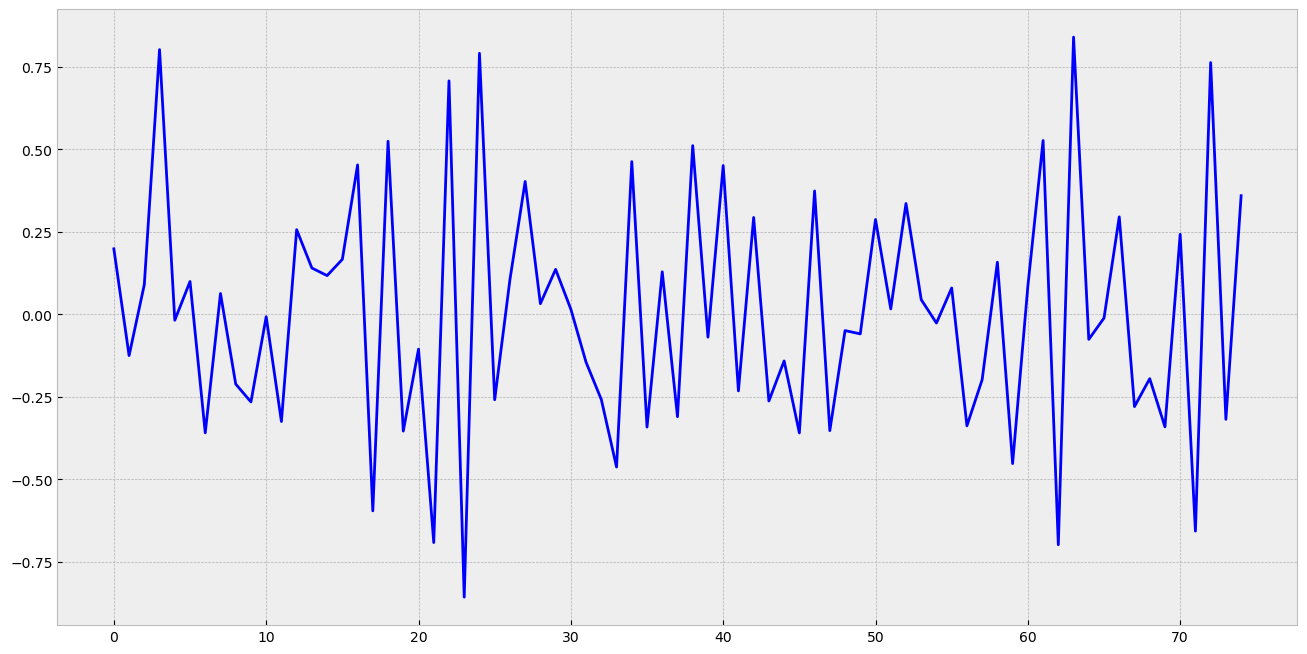

In [120]:
series_2 = np.diff(series_2,1)
print_graph(series_2)

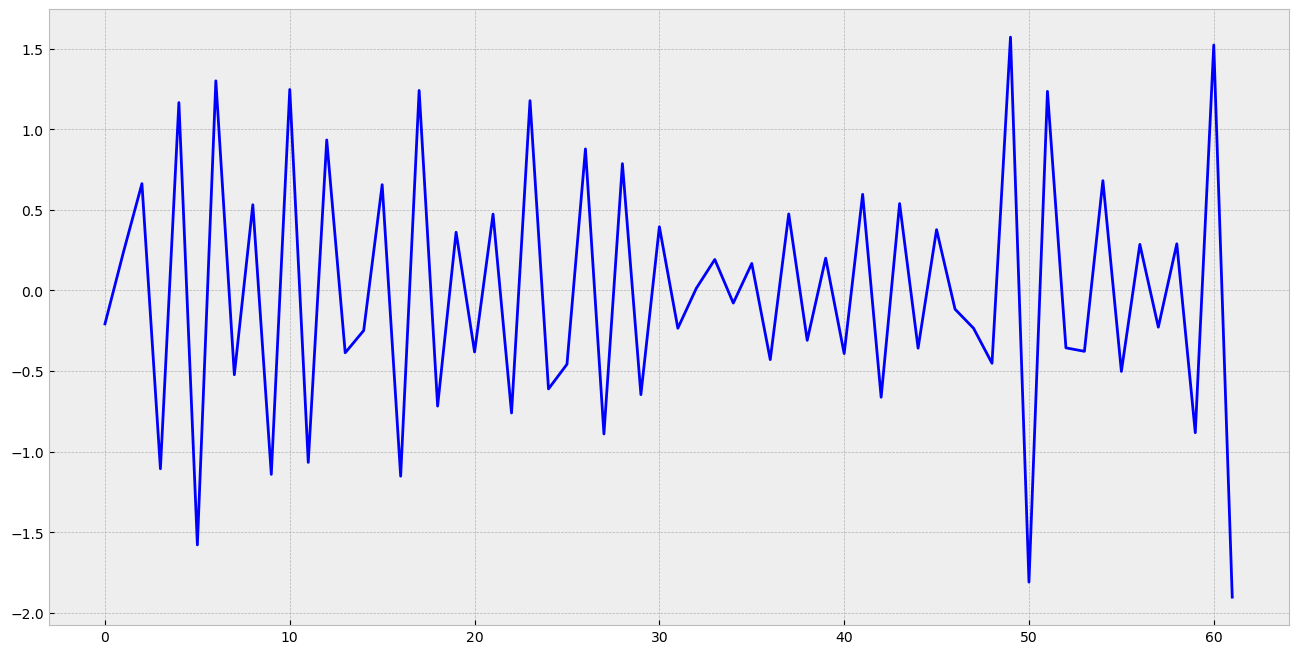

In [121]:
series_3 = np.diff(series_2,1)
series_3 = series_3[:-12] - series_3[12:]
print_graph(series_3)

Проверим наличие стационарности с помощью теста Дики-Фулера

In [122]:
test_stationarity(series_3)

Results of Dickey-Fuller Test:
Test Statistic                 -4.799723
p-value                         0.000054
#Lags Used                     11.000000
Number of Observations Used    50.000000
Critical Value (1%)            -3.568486
Critical Value (5%)            -2.921360
Critical Value (10%)           -2.598662
dtype: float64


**p-value < 0.05, следовательно, ряд стационарен. На самом деле, если проверить ряд после первого дифферецирования, он уже становится стационарным, поскольку p-value series_2 = 0.02. Следовательно, можно сделать вывод, что в первую очередь необходимо было нормализовать распределение дисперсии.**


#### Анализ ряда "Monthly Boston armed robberies" и приведение его к стационарному виду

Перед тем, как определить сезонность, нормализуем дисперсию ряда, так как она монотонно растет

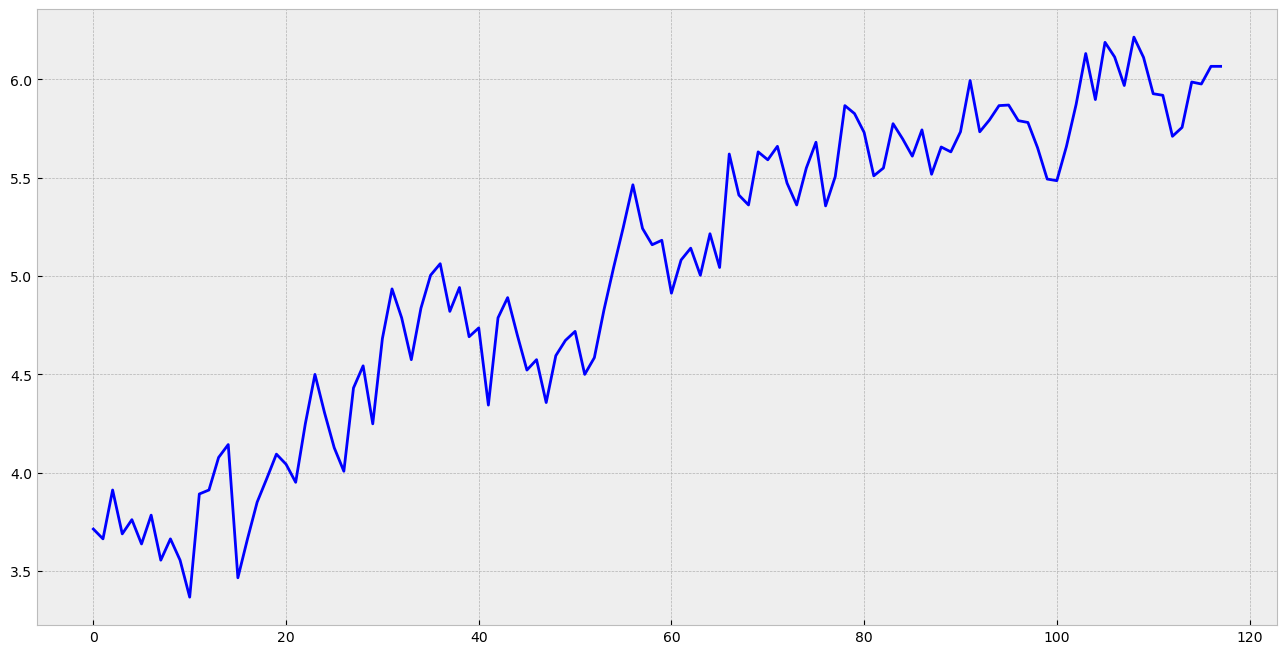

In [132]:
series_montly_boston = boxcox(all_series['Monthly Boston armed robberies'],0)
series_montly_boston = pd.Series(series_montly_boston)
print_graph(series_montly_boston)

Определение сезонности

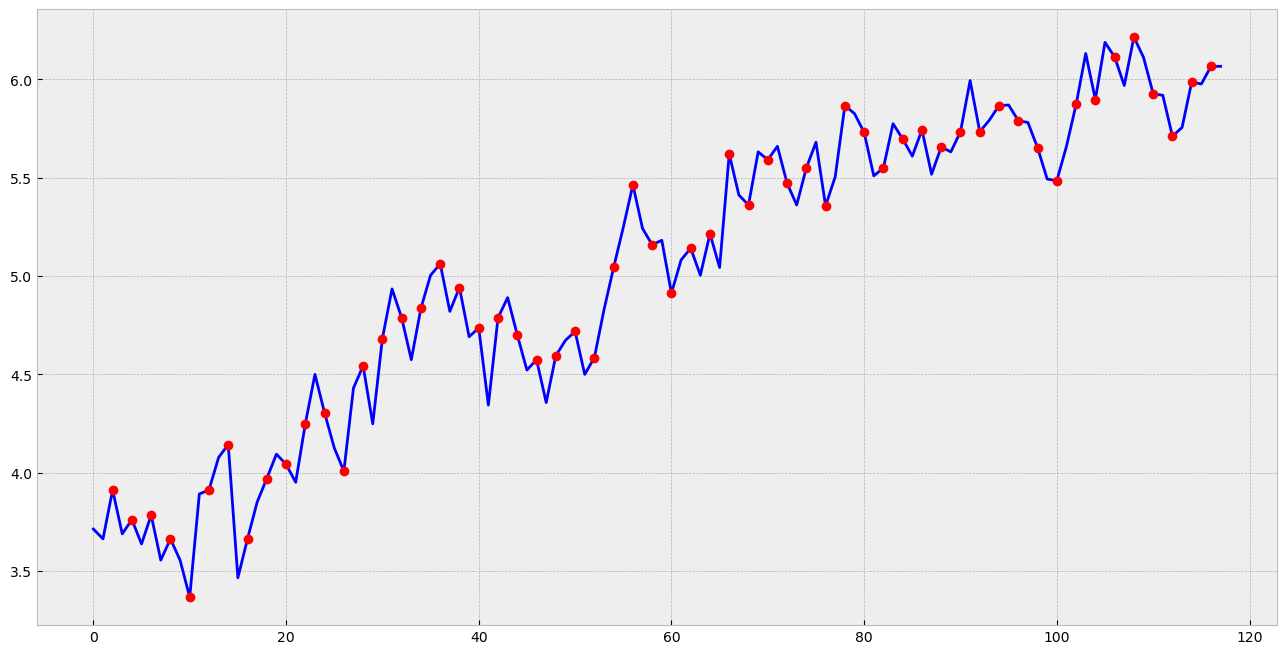

In [117]:
plot_ts_and_points(series_montly_boston,2,2)

На данный момент нет возможности точно определить период ряда, поэтому примем его пока равным 2

Проведем дифференцирование 1 порядка для избавления от ярко выраженного тренда


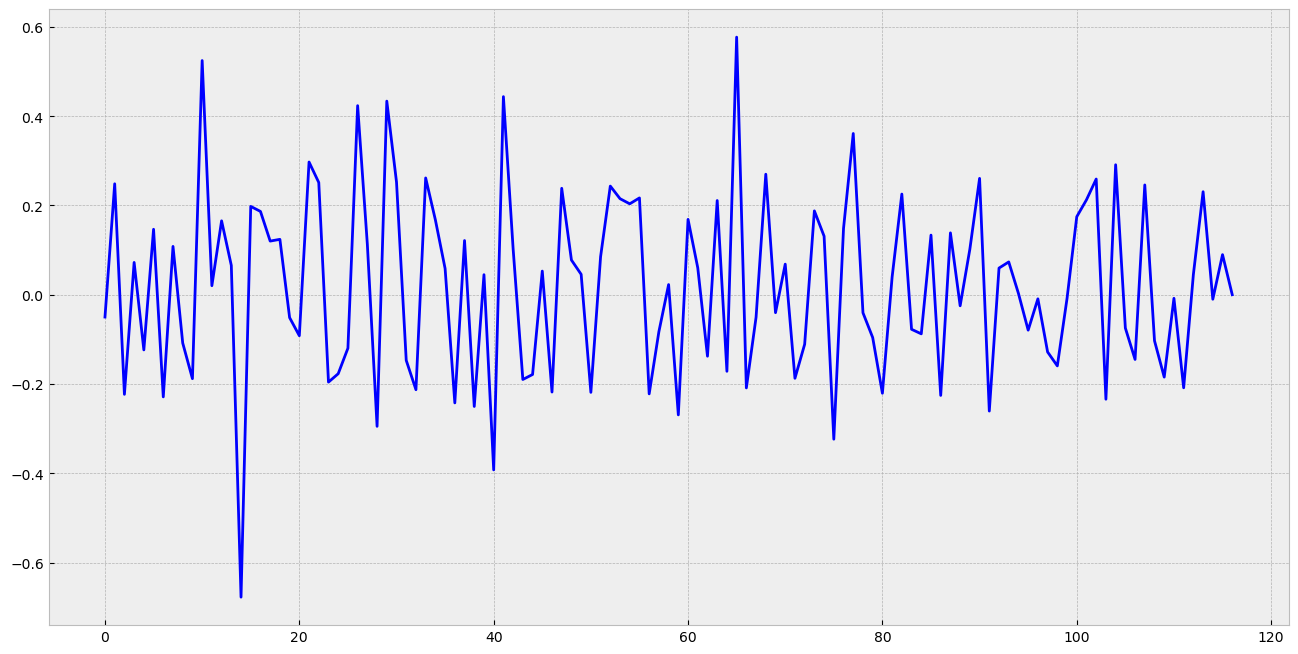

In [134]:
series_montly_boston_dif = np.diff(series_montly_boston,1)
print_graph(series_montly_boston_dif)

Проверка гипотезы стационарности

In [135]:
test_stationarity(series_montly_boston_dif)

Results of Dickey-Fuller Test:
Test Statistic                -7.601792e+00
p-value                        2.378602e-11
#Lags Used                     3.000000e+00
Number of Observations Used    1.130000e+02
Critical Value (1%)           -3.489590e+00
Critical Value (5%)           -2.887477e+00
Critical Value (10%)          -2.580604e+00
dtype: float64


Гипотеза стационарности принимается, p-value < 0.05, следовательно, ряд стационарен

#### Анализ ряда "International airline passengers: monthly totals in thousands" и приведение ряда к стационарному виду

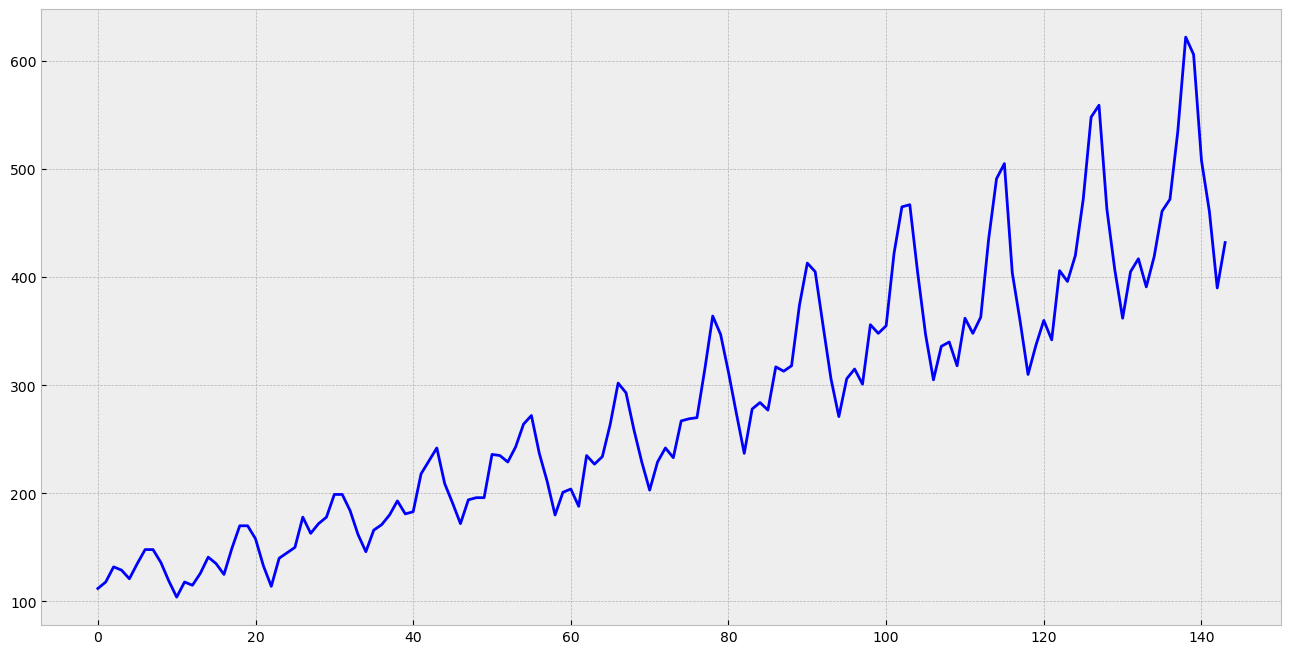

In [137]:
series_international_arline = all_series['International airline passengers: monthly totals in thousands']
print_graph(series_international_arline)

У ряда наблюдается явно выраженный тренд, сезонность и колебания дисперсии. Выполним все последовательно - нормализуем дисперсию, избавимся от тренда и от сезонности

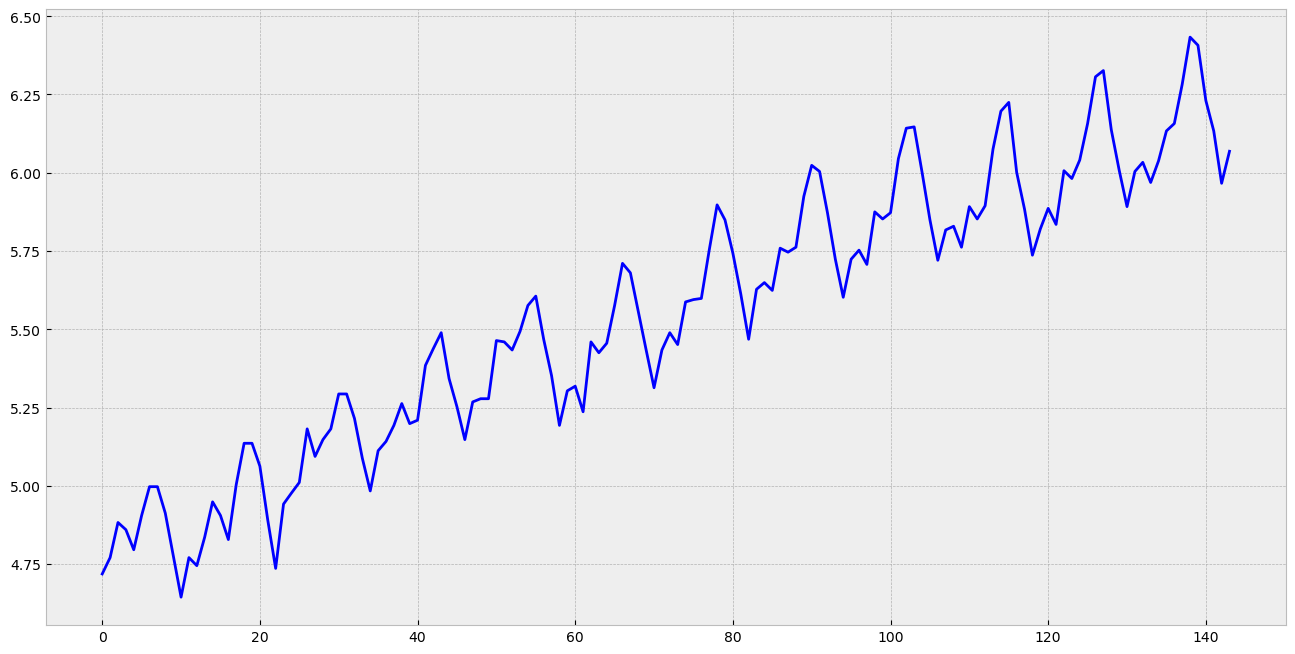

In [138]:
series_international_arline = boxcox(series_international_arline,0)
series_international_arline = pd.Series(series_international_arline)
print_graph(series_international_arline)

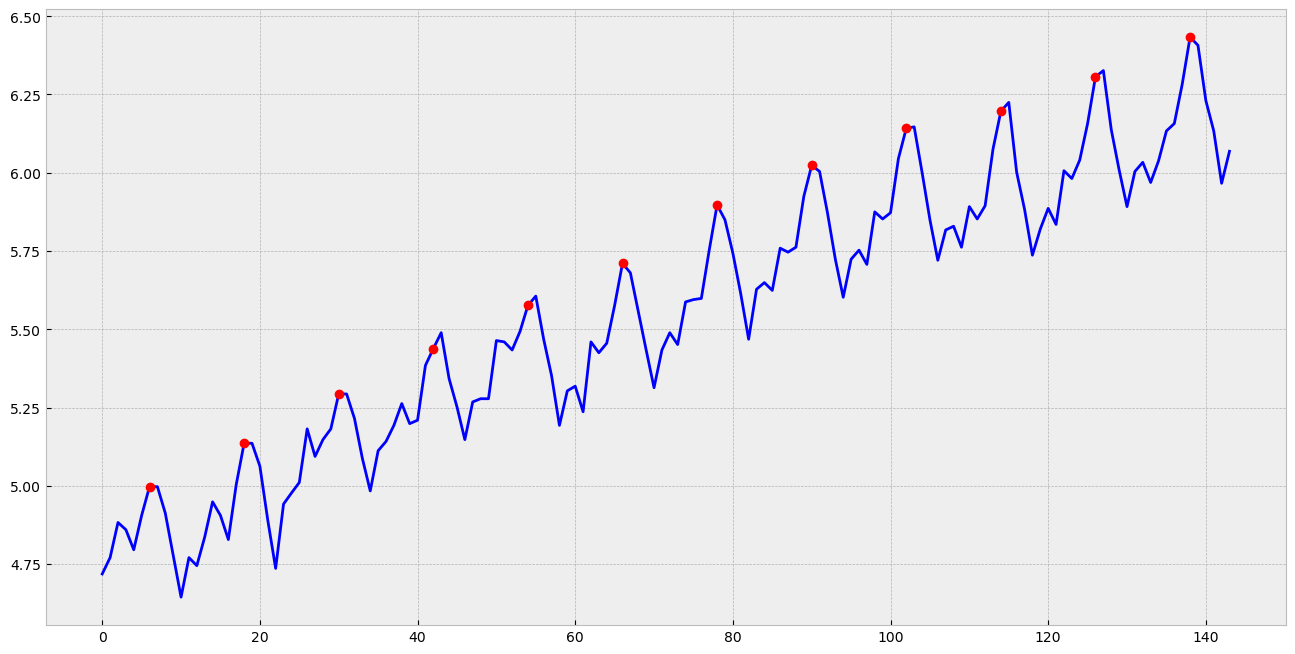

In [143]:
plot_ts_and_points(series_international_arline,start_point=6, step=12)

Сделаем двойное дифференцирование - сначала по логу 1, затем по логу 12

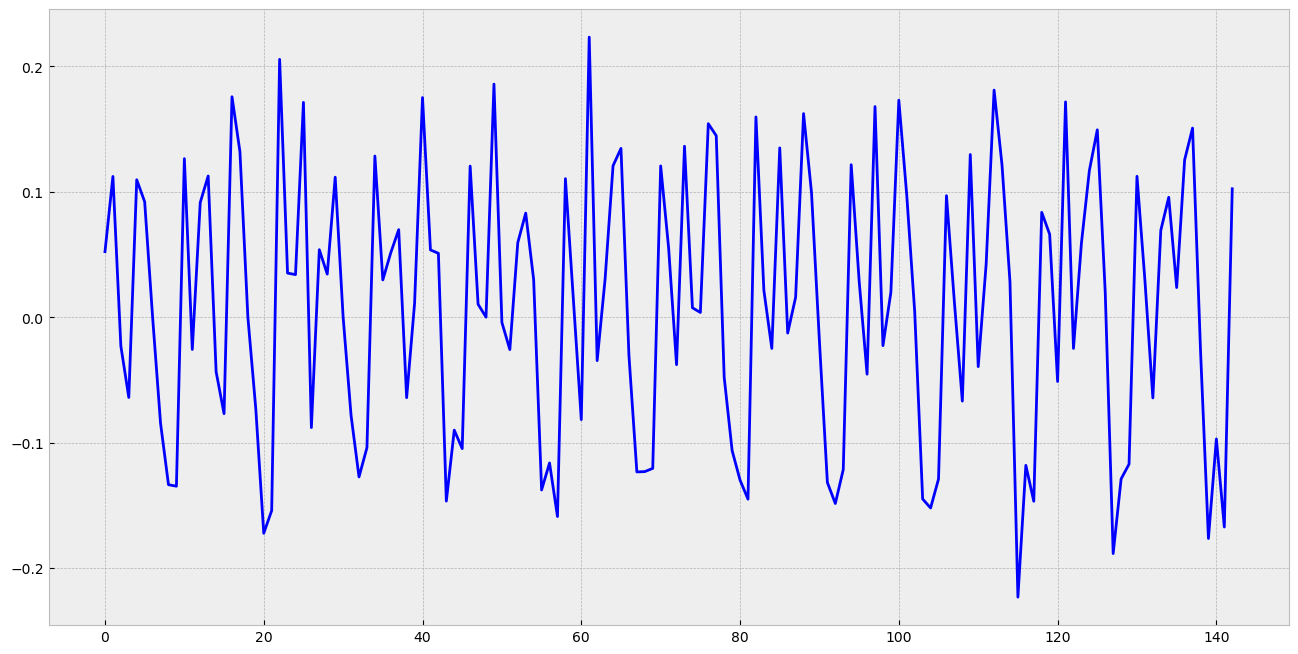

In [144]:
series_international_arline_diff = np.diff(series_international_arline,1)
print_graph(series_international_arline_diff)

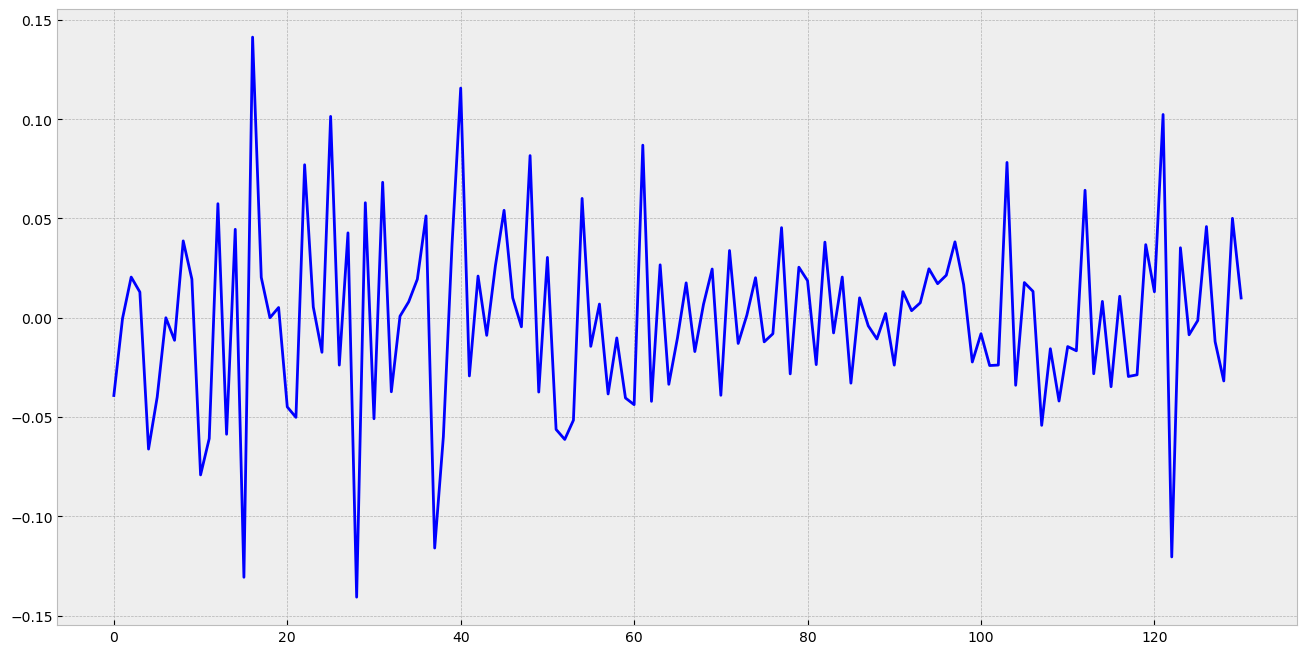

In [145]:
series_international_arline_diff_12 = series_international_arline_diff[:-12] - series_international_arline_diff[12:]
print_graph(series_international_arline_diff_12)

Проверка гипотезы о стационарности

In [148]:
test_stationarity(series_international_arline_diff_12)

Results of Dickey-Fuller Test:
Test Statistic                  -4.443325
p-value                          0.000249
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64


Ряд приведен к стационарному

#### Анализ ряда ""Mean monthly air temperature (Deg. F) Nottingham Castle"" и приведение ряда к стационарному виду

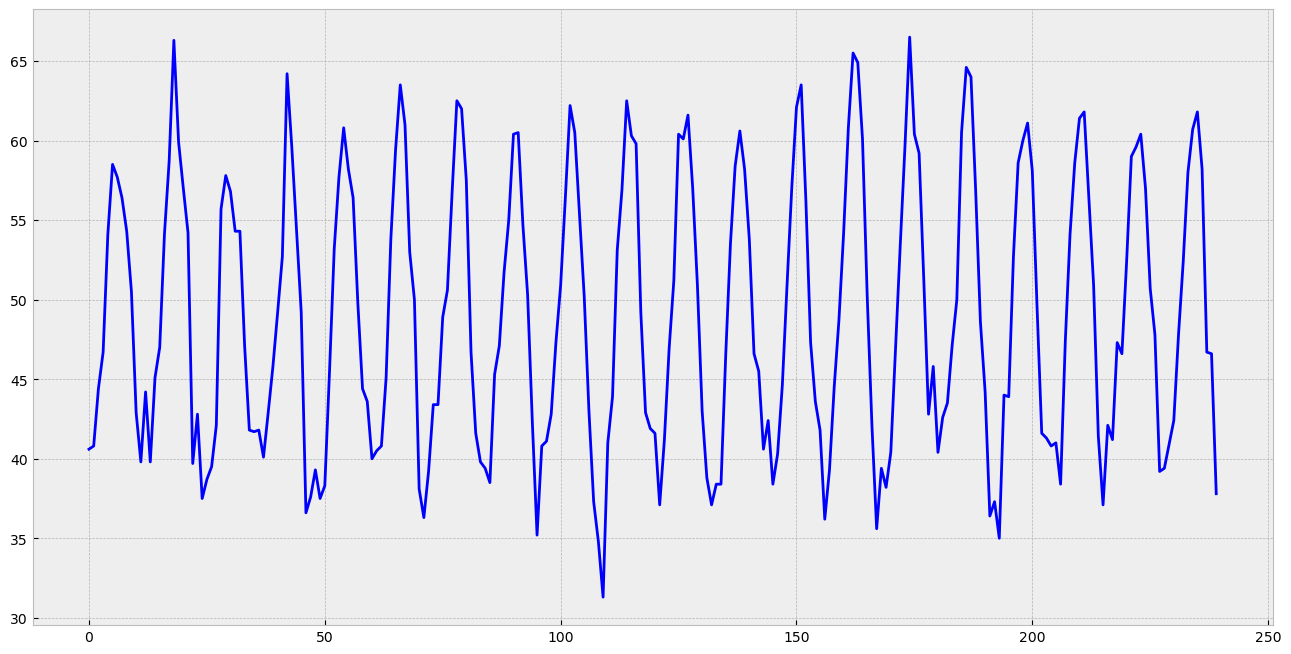

In [150]:
series_temp_castle = all_series["Mean monthly air temperature (Deg. F) Nottingham Castle"]
print_graph(series_temp_castle)

На первый взгляд ряд выглядит как стационарный, проверим гипотезу

In [151]:
test_stationarity(series_temp_castle)

Results of Dickey-Fuller Test:
Test Statistic                  -3.255492
p-value                          0.016989
#Lags Used                      14.000000
Number of Observations Used    225.000000
Critical Value (1%)             -3.459752
Critical Value (5%)             -2.874473
Critical Value (10%)            -2.573663
dtype: float64


Гипотеза подтвердилась, ряд стационарен

#### Анализ ряда "Weekly closings of the Dow-Jones industrial average" и приведение ряда к стационарному виду

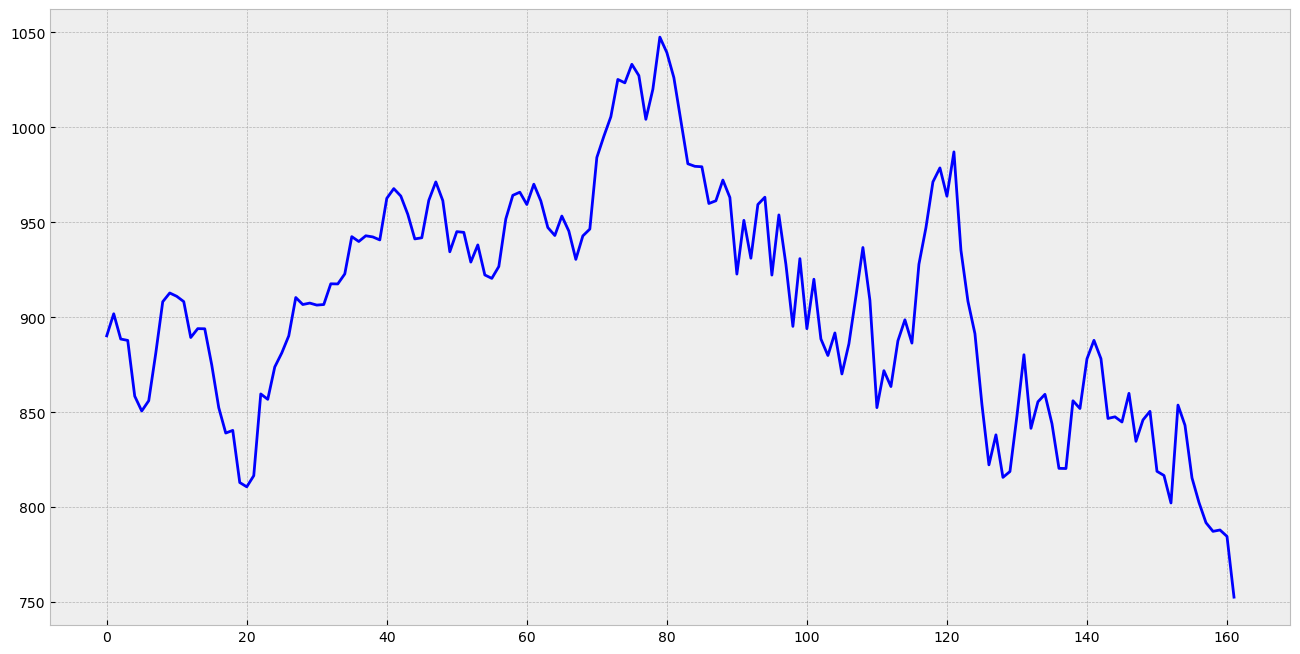

In [152]:
series_weekly_closing = all_series["Weekly closings of the Dow-Jones industrial average"]
print_graph(series_weekly_closing)

Ряд не имеет явно выраженный тренд и не имеет сильного разроса в дисперсии. Попробуем продифференцировать ряд по сезонности

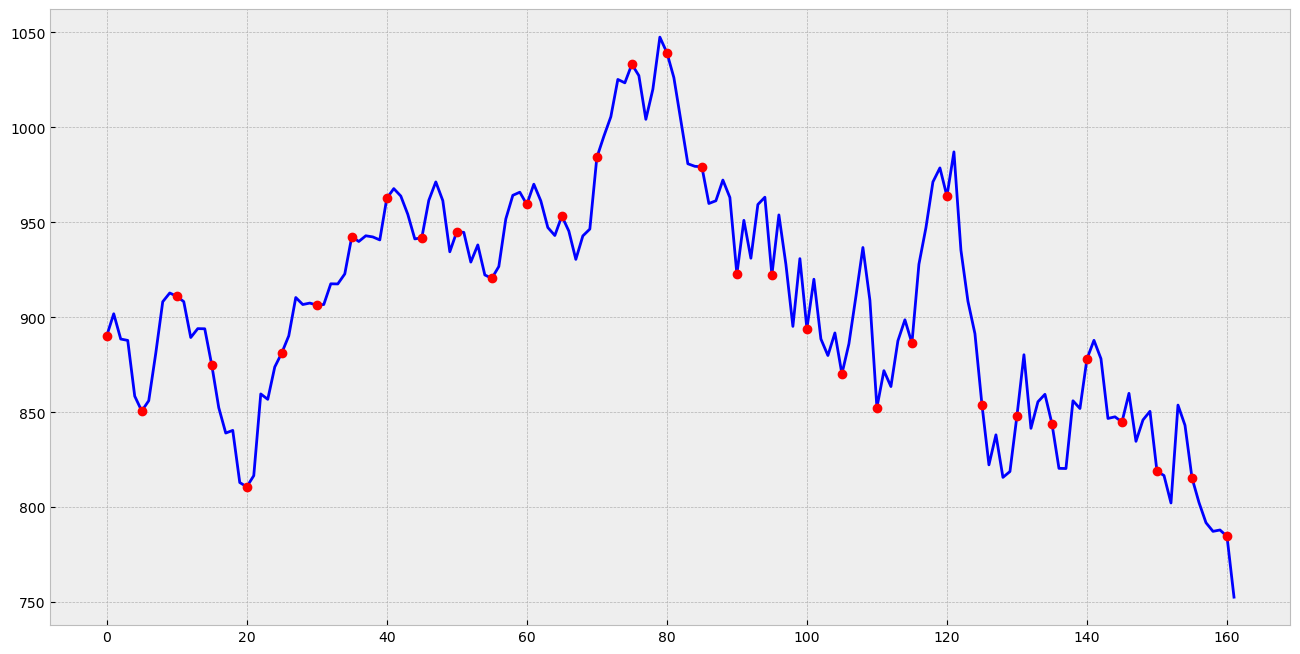

In [163]:
plot_ts_and_points(series_weekly_closing,start_point=0,step=5)

Сезонность определить сложно, попробуем продифференцировать по лагам 1,2,3,4,5,6

In [189]:

arr_log = [1,2,3,4,5,6]
def diff_log(arr,data):
    data= np.diff(data,1)
    data = pd.Series(data)
    series_dict = {}
    for n in arr:
        data_diff = data.diff(n).dropna()   # 👈 вот здесь замена
        dftest = adfuller(data_diff, autolag='AIC')
        series_dict[f'log {n}, p-value = {dftest[1]}'] = data_diff
        

    with plt.style.context('bmh'):
        plt.figure(figsize=(16, 8))
        layout = (3, 2)
        
        for i, key in enumerate(series_dict.keys()):
            x = i % 2
            y = int((i - x) / 2) ## задаем координаты области, в которой будет находиться подграфик 
        
            ts_ax = plt.subplot2grid(layout, (y, x)) ## создаем область для подграфика 
            series_dict[key].plot(ax=ts_ax, color='blue')
            ts_ax.set_title(key)
        
        plt.tight_layout() ## подгоняет графики, чтобы они не налезали друг на друга


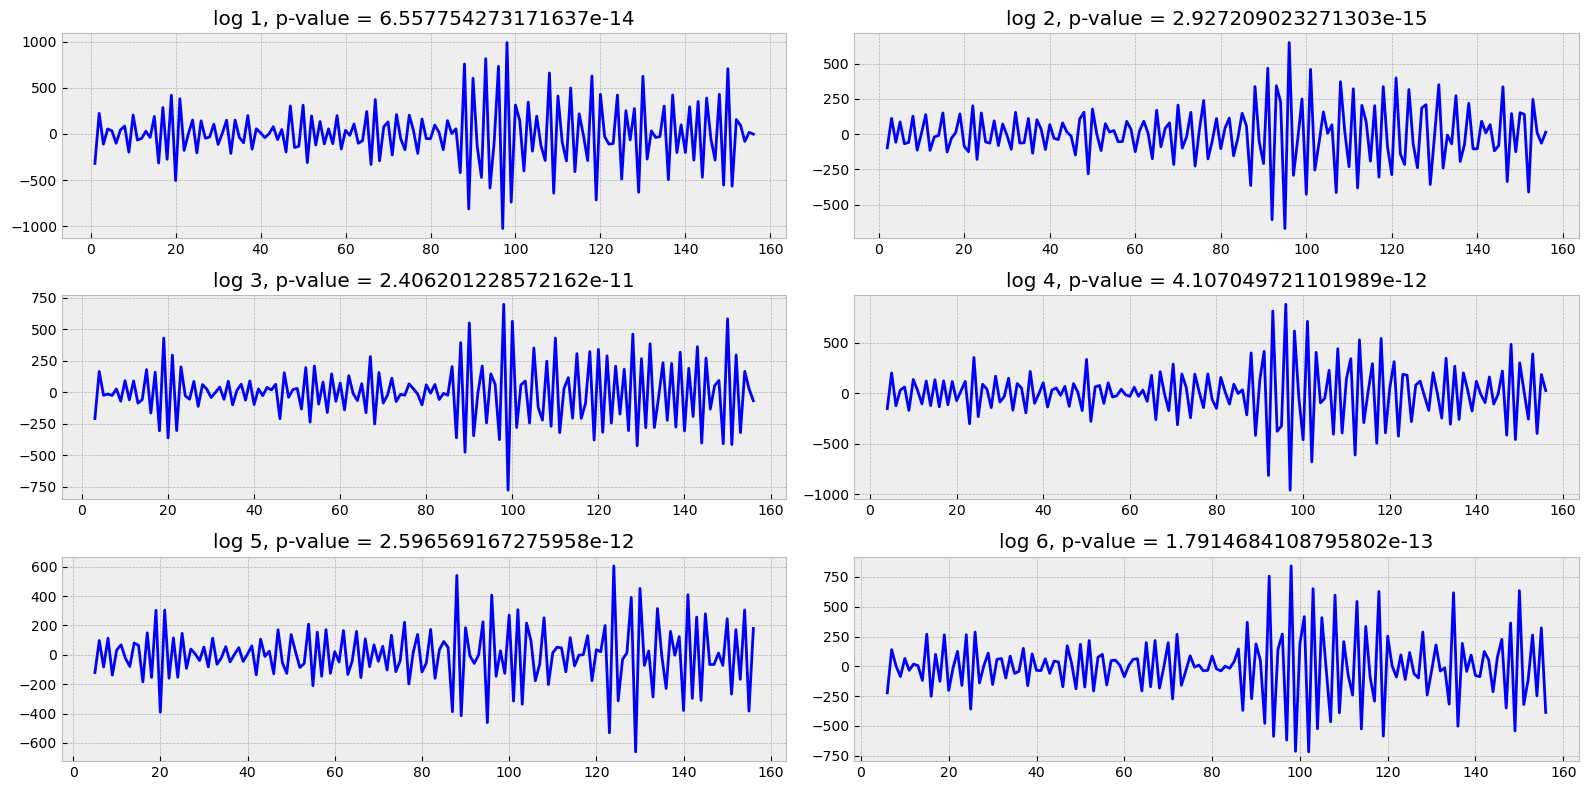

In [190]:
diff_log(arr_log,series_weekly_closing)

Для приведения ряда к стационарному виду

#### Анализ ряда "Daily total female births in California" и приведение ряда к стационарному виду

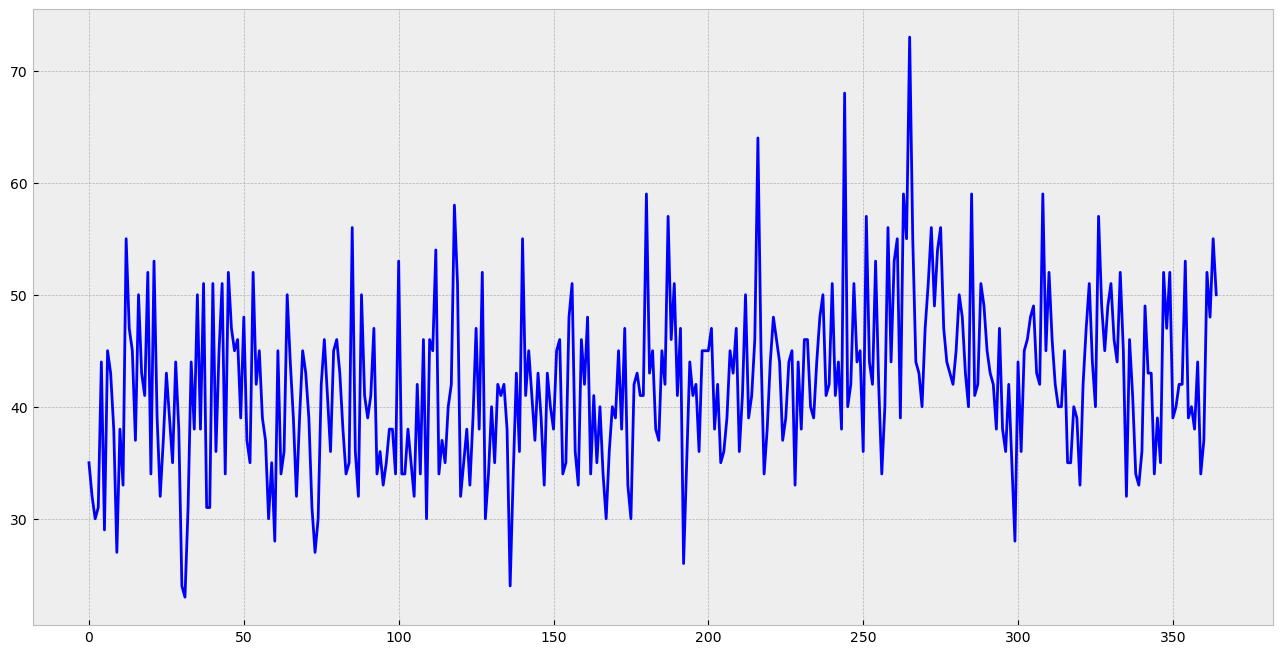

In [191]:
series_female_births = all_series['Daily total female births in California']
print_graph(series_female_births)

Проверим гипотезу стационарности, так как ряд с первого взгляда выглядит как стационарный

In [192]:
test_stationarity(series_female_births)

Results of Dickey-Fuller Test:
Test Statistic                  -4.808291
p-value                          0.000052
#Lags Used                       6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089
dtype: float64


Гипотеза подтвердилась, ряд стационарный